# `CONTENT MONETIZATION MODELER`


In [541]:
# Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

import warnings
warnings.filterwarnings('ignore')

# `Dataset Overview`


In [542]:
# Load dataset
df = pd.read_csv(r"C:\Users\RAaM\OneDrive\Desktop\Monetory\youtube_ad_revenue_dataset.csv")

In [543]:
# Load top 10 rows 
df.head(10)

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
5,vid_5000,2025-03-31 10:50:40.993199,10002,843.0,159.0,35131.756228,12.491826,541268,Music,TV,CA,234.965996
6,vid_2041,2024-12-10 10:50:40.993199,9989,1944.0,160.0,35380.070908,6.520903,193736,Music,Mobile,IN,255.009412
7,vid_3623,2025-04-05 10:50:40.993199,10051,784.0,458.0,19263.212580,24.586121,823662,Entertainment,Tablet,US,164.533455
8,vid_750,2025-02-17 10:50:40.993199,9934,292.0,88.0,NaN,5.946666,58437,Entertainment,Desktop,UK,336.409856
9,vid_4434,2025-04-16 10:50:40.993199,10051,NaN,61.0,40011.579945,24.454723,103872,Tech,Tablet,DE,246.711883


In [544]:
# Print the shape and info of teh dataset
print("Shape : ",df.shape)
print(df.info())

Shape :  (122400, 12)
<class 'pandas.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  str    
 1   date                  122400 non-null  str    
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  str    
 9   device                122400 non-null  str    
 10  country               122400 non-null  str    
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), str(5)
memory usage: 16.9 MB
None


In [545]:
#summarizing the stats of the data
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


# `Missing Values`

In [546]:
# Checking the missing values
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

# `Duplicate Values`

In [547]:
# checking for duplicate values
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# Display duplicate rows
duplicate_rows = df[df.duplicated()]
duplicate_rows

Total duplicate rows: 2400


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
3179,vid_4608,2025-01-11 10:50:40.993199,9945,1458.0,121.0,31645.774111,15.206639,224801,Tech,Desktop,CA,228.151319
3231,vid_3134,2025-06-05 10:50:40.993199,10077,701.0,202.0,40120.596261,12.656050,580825,Tech,TV,UK,257.175292
3666,vid_25,2024-09-18 10:50:40.993199,9947,1802.0,347.0,55506.461433,5.456635,385325,Tech,Tablet,DE,350.450592
4710,vid_4926,2024-10-24 10:50:40.993199,9995,1286.0,292.0,34484.070853,4.757113,606881,Education,TV,DE,241.775903
4818,vid_4966,2025-02-10 10:50:40.993199,10034,776.0,447.0,34912.309423,2.488627,46916,Entertainment,Mobile,DE,237.896544
...,...,...,...,...,...,...,...,...,...,...,...,...
122163,vid_4644,2024-08-25 10:50:40.993199,10047,1948.0,307.0,16349.810313,10.084170,176249,Gaming,Mobile,IN,168.188062
122237,vid_2558,2024-07-27 10:50:40.993199,10028,1273.0,149.0,46832.765101,19.829163,733749,Tech,Tablet,DE,297.484978
122263,vid_4264,2024-09-30 10:50:40.993199,10035,563.0,457.0,NaN,10.365727,892745,Gaming,TV,AU,162.047770
122269,vid_2012,2025-06-07 10:50:40.993199,9919,688.0,152.0,58706.831545,18.868730,816381,Lifestyle,Mobile,IN,342.894716


# `EDA`

In [548]:
# Data Cleaning & Preprocessing

## 1. Droping the 'id' column
X = df.drop('video_id', axis=1)

In [549]:
## 2. Changing the date format

X['date'] = pd.to_datetime(df['date'],format='%Y-%m-%d %H:%M:%S.%f')
X['date'] = X['date'].dt.strftime('%Y-%m-%d %H:%M:%S')

In [550]:
## 3. Handling Missing Values

X['likes'] = X['likes'].fillna(X['likes'].median())
X['comments'] = X['comments'].fillna(X['comments'].median())
X['watch_time_minutes'] = X['watch_time_minutes'].fillna(X['watch_time_minutes'].median())
X.isnull().sum()

date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

In [551]:
## 4. Handling Duplicate Records 

X = X.drop_duplicates()
print("Dataset shape after removing duplicates:", X.shape)

Dataset shape after removing duplicates: (120000, 11)


# `Outlier Detection`

views: 865 outliers
likes: 0 outliers
comments: 0 outliers
watch_time_minutes: 0 outliers
video_length_minutes: 0 outliers
subscribers: 0 outliers
ad_revenue_usd: 0 outliers


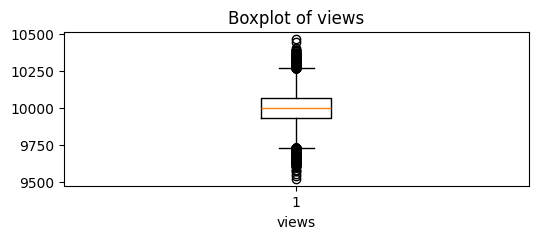

In [552]:
# Detect Outlier

numerical_columns = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'ad_revenue_usd'
]

for col in numerical_columns:

    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = X[(X[col] < lower) | (X[col] > upper)].shape[0]
    print(f"{col}: {outlier_count} outliers")


#Visualization 

plt.figure(figsize=(6,2))
plt.boxplot(X['views'], vert=True)
plt.title(f'Boxplot of views')
plt.xlabel('views')
plt.show()

# `Skewness Analysis`

comments          0.008859
ad_revenue_usd    0.000948
views            -0.002912
likes            -0.003271
subscribers      -0.009575
dtype: float64
             Original  Log Transformed
views       -0.002912        -0.033136
likes       -0.003271        -0.834900
comments     0.008859        -0.825202
subscribers -0.009575        -1.802185


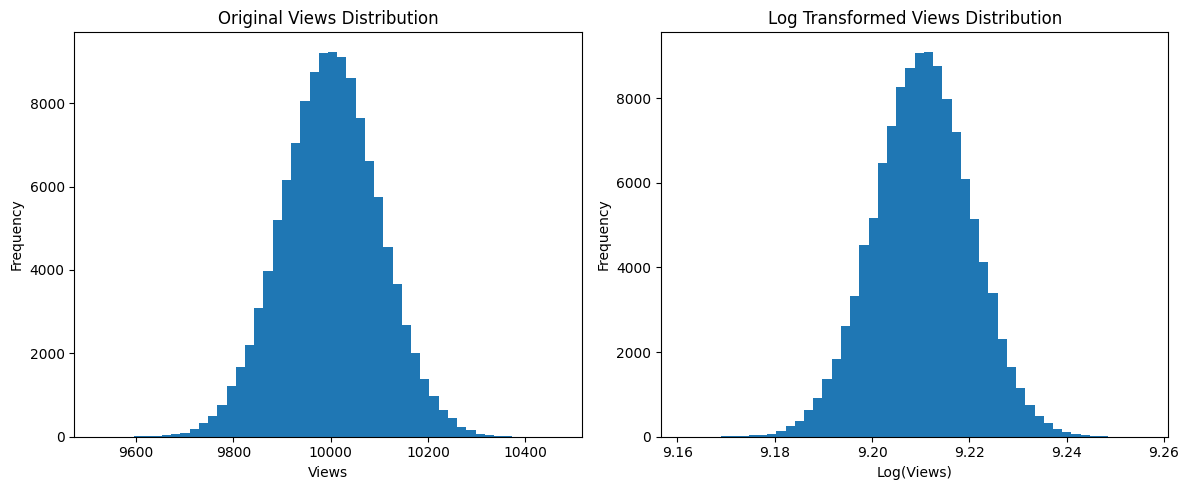

In [553]:
# Check Skewness

numerical_columns = ['views','likes', 'comments', 'subscribers', 'ad_revenue_usd']
print(X[numerical_columns].skew().sort_values(ascending=False))

# Apply Log Transformation
X['log_views'] = np.log1p(X['views'])
X['log_likes'] = np.log1p(X['likes'])
X['log_comments'] = np.log1p(X['comments'])
X['log_subscribers'] = np.log1p(X['subscribers'])

# Compare Skewness Before and After
comparison = pd.DataFrame({
    'Original': X[['views','likes','comments','subscribers']].skew(),
    'Log Transformed': X[['log_views','log_likes','log_comments','log_subscribers']].skew().values
})

print(comparison)


# Visualize the Effect


plt.figure(figsize=(12,5))

# Original distribution
plt.subplot(1,2,1)
plt.hist(df['views'], bins=50)
plt.title("Original Views Distribution")
plt.xlabel("Views")
plt.ylabel("Frequency")

# Log-transformed distribution
plt.subplot(1,2,2)
plt.hist(X['log_views'], bins=50)
plt.title("Log Transformed Views Distribution")
plt.xlabel("Log(Views)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# `Feature Engineering `


In [554]:
# Feature Engineering 

## 1. Convert Date Features

X['date'] = pd.to_datetime(X['date'],format='mixed',errors='coerce')
X['year'] = X['date'].dt.year
X['month'] = X['date'].dt.month
X['day'] = X['date'].dt.day
X['day_of_week'] = X['date'].dt.day_name()
X

,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,log_views,log_likes,log_comments,log_subscribers,year,month,day,day_of_week
0,2024-09-24 10:50:40,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,9.204020,7.108244,5.771441,12.337482,2024,9,24,Tuesday
1,2024-09-22 10:50:40,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,9.212139,6.466145,5.849325,13.509007,2024,9,22,Sunday
2,2024-11-21 10:50:40,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,9.220093,7.590852,5.236442,12.390621,2024,11,21,Thursday
3,2025-01-28 10:50:40,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,9.213834,7.083388,5.493061,12.981912,2025,1,28,Tuesday
4,2025-04-28 10:50:40,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,9.199279,7.527794,6.169611,10.646163,2025,4,28,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,2024-12-14 10:50:40,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,9.195633,7.422971,4.997212,12.258755,2024,12,14,Saturday
122396,2024-07-13 10:50:40,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,9.223158,7.444249,4.158883,13.686382,2024,7,13,Saturday
122397,2024-06-10 10:50:40,10267,700.0,274.0,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,9.236788,6.552508,5.616771,13.265176,2024,6,10,Monday
122398,2024-12-22 10:50:40,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,9.234155,7.388328,4.672829,13.279605,2024,12,22,Sunday


In [555]:
## 2. Engagement Rate

X['engagement_rate'] = ((X['likes'] + X['comments']) / X['views'].replace(0, np.nan) )
print(X['engagement_rate'].isnull().sum())
X

0


,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,log_views,log_likes,log_comments,log_subscribers,year,month,day,day_of_week,engagement_rate
0,2024-09-24 10:50:40,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,9.204020,7.108244,5.771441,12.337482,2024,9,24,Tuesday,0.155093
1,2024-09-22 10:50:40,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,9.212139,6.466145,5.849325,13.509007,2024,9,22,Sunday,0.098632
2,2024-11-21 10:50:40,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,9.220093,7.590852,5.236442,12.390621,2024,11,21,Thursday,0.214519
3,2025-01-28 10:50:40,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,9.213834,7.083388,5.493061,12.981912,2025,1,28,Tuesday,0.142814
4,2025-04-28 10:50:40,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,9.199279,7.527794,6.169611,10.646163,2025,4,28,Monday,0.236121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,2024-12-14 10:50:40,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,9.195633,7.422971,4.997212,12.258755,2024,12,14,Saturday,0.184715
122396,2024-07-13 10:50:40,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,9.223158,7.444249,4.158883,13.686382,2024,7,13,Saturday,0.174961
122397,2024-06-10 10:50:40,10267,700.0,274.0,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,9.236788,6.552508,5.616771,13.265176,2024,6,10,Monday,0.094867
122398,2024-12-22 10:50:40,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,9.234155,7.388328,4.672829,13.279605,2024,12,22,Sunday,0.168164


In [556]:

## 3. Like Ratio 

X['like_ratio'] = X['likes'] / X['views'].replace(0, np.nan)
print(X['like_ratio'].isnull().sum())
X

0


,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,...,log_views,log_likes,log_comments,log_subscribers,year,month,day,day_of_week,engagement_rate,like_ratio
0,2024-09-24 10:50:40,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,...,9.204020,7.108244,5.771441,12.337482,2024,9,24,Tuesday,0.155093,0.122886
1,2024-09-22 10:50:40,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,...,9.212139,6.466145,5.849325,13.509007,2024,9,22,Sunday,0.098632,0.064091
2,2024-11-21 10:50:40,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,...,9.220093,7.590852,5.236442,12.390621,2024,11,21,Thursday,0.214519,0.195999
3,2025-01-28 10:50:40,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,...,9.213834,7.083388,5.493061,12.981912,2025,1,28,Tuesday,0.142814,0.118696
4,2025-04-28 10:50:40,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,...,9.199279,7.527794,6.169611,10.646163,2025,4,28,Monday,0.236121,0.187886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,2024-12-14 10:50:40,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,...,9.195633,7.422971,4.997212,12.258755,2024,12,14,Saturday,0.184715,0.169796
122396,2024-07-13 10:50:40,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,...,9.223158,7.444249,4.158883,13.686382,2024,7,13,Saturday,0.174961,0.168740
122397,2024-06-10 10:50:40,10267,700.0,274.0,27549.714659,23.822365,576756,Tech,Tablet,CA,...,9.236788,6.552508,5.616771,13.265176,2024,6,10,Monday,0.094867,0.068180
122398,2024-12-22 10:50:40,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,...,9.234155,7.388328,4.672829,13.279605,2024,12,22,Sunday,0.168164,0.157812


In [557]:
## 4. Watch Time per View

X['watch_time_per_view'] = (X['watch_time_minutes'] / X['views'].replace(0, np.nan))
print(X['watch_time_per_view'].isnull().sum())
X


0


,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,...,log_likes,log_comments,log_subscribers,year,month,day,day_of_week,engagement_rate,like_ratio,watch_time_per_view
0,2024-09-24 10:50:40,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,...,7.108244,5.771441,12.337482,2024,9,24,Tuesday,0.155093,0.122886,2.666789
1,2024-09-22 10:50:40,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,...,6.466145,5.849325,13.509007,2024,9,22,Sunday,0.098632,0.064091,1.518393
2,2024-11-21 10:50:40,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,...,7.590852,5.236442,12.390621,2024,11,21,Thursday,0.214519,0.195999,5.678187
3,2025-01-28 10:50:40,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,...,7.083388,5.493061,12.981912,2025,1,28,Tuesday,0.142814,0.118696,3.122834
4,2025-04-28 10:50:40,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,...,7.527794,6.169611,10.646163,2025,4,28,Monday,0.236121,0.187886,1.584151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,2024-12-14 10:50:40,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,...,7.422971,4.997212,12.258755,2024,12,14,Saturday,0.184715,0.169796,4.270345
122396,2024-07-13 10:50:40,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,...,7.444249,4.158883,13.686382,2024,7,13,Saturday,0.174961,0.168740,5.683620
122397,2024-06-10 10:50:40,10267,700.0,274.0,27549.714659,23.822365,576756,Tech,Tablet,CA,...,6.552508,5.616771,13.265176,2024,6,10,Monday,0.094867,0.068180,2.683327
122398,2024-12-22 10:50:40,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,...,7.388328,4.672829,13.279605,2024,12,22,Sunday,0.168164,0.157812,5.563221


In [558]:
## 5.Video Length Category 

def video_length_category(x):
    if x < 5:
        return 'Short'
    elif (x >= 5) & (x <= 15):
        return 'Medium'
    else:
        return 'Long'

X['video_length_category'] = X['video_length_minutes'].apply(video_length_category)
X

,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,...,log_comments,log_subscribers,year,month,day,day_of_week,engagement_rate,like_ratio,watch_time_per_view,video_length_category
0,2024-09-24 10:50:40,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,...,5.771441,12.337482,2024,9,24,Tuesday,0.155093,0.122886,2.666789,Short
1,2024-09-22 10:50:40,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,...,5.849325,13.509007,2024,9,22,Sunday,0.098632,0.064091,1.518393,Long
2,2024-11-21 10:50:40,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,...,5.236442,12.390621,2024,11,21,Thursday,0.214519,0.195999,5.678187,Long
3,2025-01-28 10:50:40,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,...,5.493061,12.981912,2025,1,28,Tuesday,0.142814,0.118696,3.122834,Medium
4,2025-04-28 10:50:40,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,...,6.169611,10.646163,2025,4,28,Monday,0.236121,0.187886,1.584151,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,2024-12-14 10:50:40,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,...,4.997212,12.258755,2024,12,14,Saturday,0.184715,0.169796,4.270345,Long
122396,2024-07-13 10:50:40,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,...,4.158883,13.686382,2024,7,13,Saturday,0.174961,0.168740,5.683620,Long
122397,2024-06-10 10:50:40,10267,700.0,274.0,27549.714659,23.822365,576756,Tech,Tablet,CA,...,5.616771,13.265176,2024,6,10,Monday,0.094867,0.068180,2.683327,Long
122398,2024-12-22 10:50:40,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,...,4.672829,13.279605,2024,12,22,Sunday,0.168164,0.157812,5.563221,Medium


In [559]:
# Sum views per day 

views_by_day = X.groupby('day_of_week')['views'].count()
print(views_by_day)

# Days with highest views
best_day = views_by_day.idxmax()
max_views = views_by_day.max()

print(f"Most videos were watched on: {best_day}")
print(f"Total Views: {max_views:,}")

day_of_week
Friday       16964
Monday       17168
Saturday     16968
Sunday       17303
Thursday     17203
Tuesday      17225
Wednesday    17169
Name: views, dtype: int64
Most videos were watched on: Sunday
Total Views: 17,303


In [560]:
# Countries with highest views

videos_by_country = X['country'].value_counts()
print(videos_by_country)

top_country = X['country'].value_counts().idxmax()
video_count = X['country'].value_counts().max()

print(f"Country with the highest number of videos: {top_country}")
print(f"Number of videos: {video_count}")

country
CA    20198
DE    20160
IN    20156
AU    19911
UK    19893
US    19682
Name: count, dtype: int64
Country with the highest number of videos: CA
Number of videos: 20198


# ` Categorical Analysis`

In [561]:
#Encode Categorical Variables

X = pd.get_dummies(X,columns=['category', 'device', 'country', 'day_of_week','video_length_category'], drop_first=True )
X

,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,log_views,log_likes,...,country_UK,country_US,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,video_length_category_Medium,video_length_category_Short
0,2024-09-24 10:50:40,9936,1221.0,320.0,26497.214184,2.862137,228086,203.178237,9.204020,7.108244,...,False,False,False,False,False,False,True,False,False,True
1,2024-09-22 10:50:40,10017,642.0,346.0,15209.747445,23.738069,736015,140.880508,9.212139,6.466145,...,False,False,False,False,True,False,False,False,False,False
2,2024-11-21 10:50:40,10097,1979.0,187.0,57332.658498,26.200634,240534,360.134008,9.220093,7.590852,...,False,False,False,False,False,True,False,False,False,False
3,2025-01-28 10:50:40,10034,1191.0,242.0,31334.517771,11.770340,434482,224.638261,9.213834,7.083388,...,True,False,False,False,False,False,True,False,True,False
4,2025-04-28 10:50:40,9889,1858.0,477.0,15665.666434,6.635854,42030,165.514388,9.199279,7.527794,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,2024-12-14 10:50:40,9853,1673.0,147.0,42075.704885,25.490195,210818,280.986396,9.195633,7.422971,...,False,True,False,True,False,False,False,False,False,False
122396,2024-07-13 10:50:40,10128,1709.0,63.0,57563.703040,16.229133,878860,354.612981,9.223158,7.444249,...,True,False,False,True,False,False,False,False,False,False
122397,2024-06-10 10:50:40,10267,700.0,274.0,27549.714659,23.822365,576756,203.643106,9.236788,6.552508,...,False,False,True,False,False,False,False,False,False,False
122398,2024-12-22 10:50:40,10240,1616.0,106.0,56967.384382,7.753099,585138,351.525811,9.234155,7.388328,...,True,False,False,False,True,False,False,False,True,False


# ` Correlation `

In [562]:
# Check correlations of Numerical columns 

numerical_columns = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'subscribers',
    'ad_revenue_usd'
]

correlation = X[numerical_columns].corr()
print(correlation)

                       views     likes  comments  watch_time_minutes  \
views               1.000000  0.015200  0.018141            0.026065   
likes               0.015200  1.000000 -0.002030            0.002722   
comments            0.018141 -0.002030  1.000000           -0.000713   
watch_time_minutes  0.026065  0.002722 -0.000713            1.000000   
subscribers         0.000750  0.003522 -0.001525            0.004616   
ad_revenue_usd      0.037942  0.142571  0.033630            0.964052   

                    subscribers  ad_revenue_usd  
views                  0.000750        0.037942  
likes                  0.003522        0.142571  
comments              -0.001525        0.033630  
watch_time_minutes     0.004616        0.964052  
subscribers            1.000000        0.005065  
ad_revenue_usd         0.005065        1.000000  


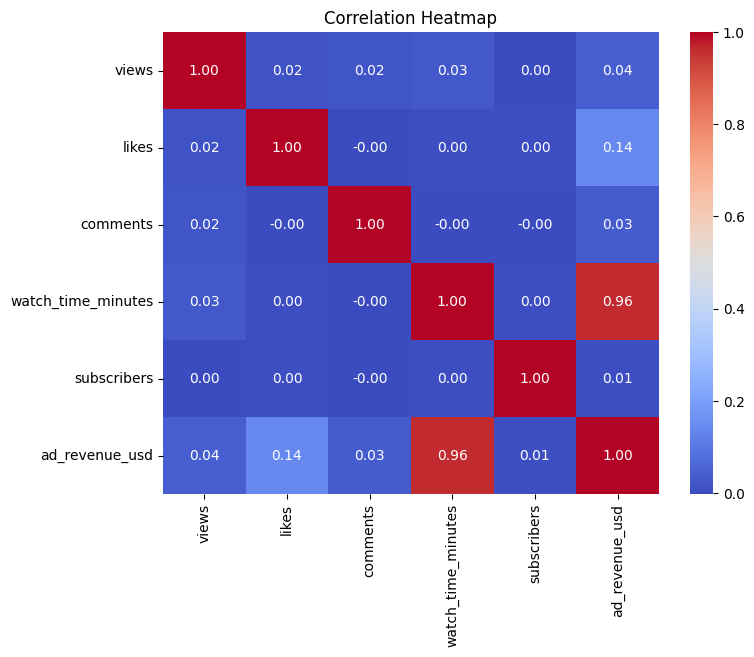

In [563]:
# Visualization of Correlation

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# `Data Visualization`

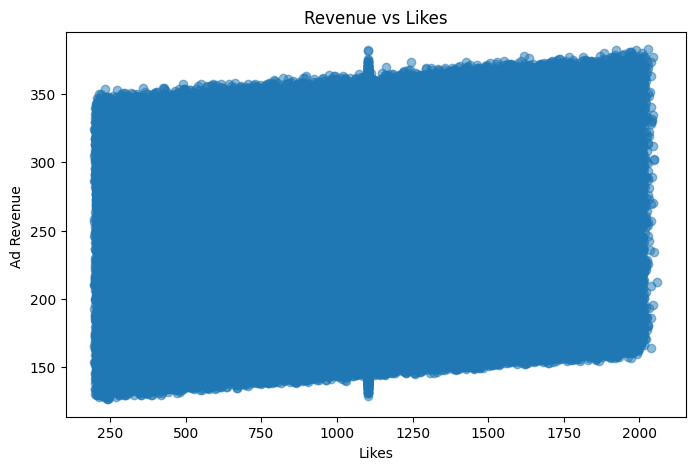

In [564]:
#1. Revenue vs Likes
   
plt.figure(figsize=(8,5)) 
plt.scatter(X['likes'], X['ad_revenue_usd'], alpha=0.5) 
plt.title('Revenue vs Likes') 
plt.xlabel('Likes') 
plt.ylabel('Ad Revenue ')
plt.show()

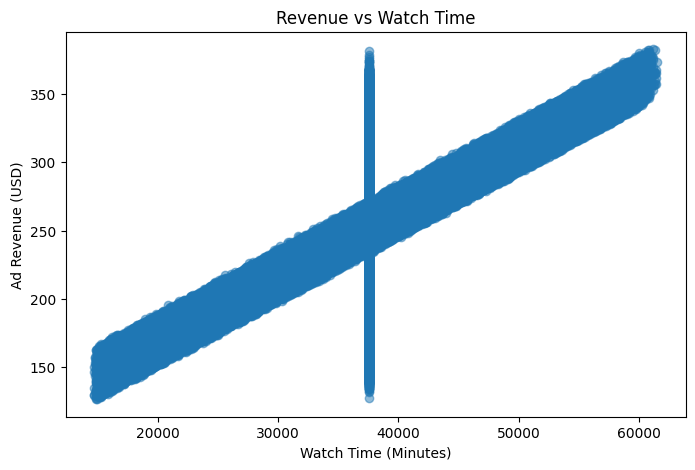

In [565]:
# 2. Revenue vs Watch Time

plt.figure(figsize=(8,5))
plt.scatter(X['watch_time_minutes'], X['ad_revenue_usd'], alpha=0.5)
plt.title('Revenue vs Watch Time')
plt.xlabel('Watch Time (Minutes)')
plt.ylabel('Ad Revenue (USD)')
plt.show()

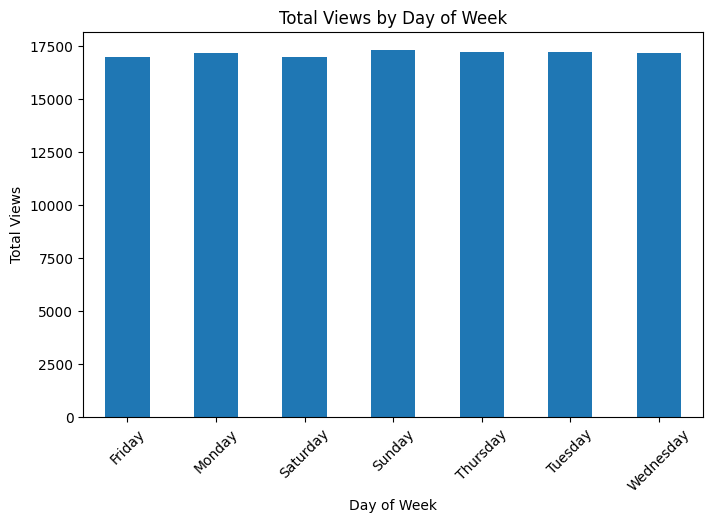

In [566]:
# 3. Views per Week Day


plt.figure(figsize=(8,5))
views_by_day.plot(kind='bar')

plt.title('Total Views by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Views')
plt.xticks(rotation=45)
plt.show()

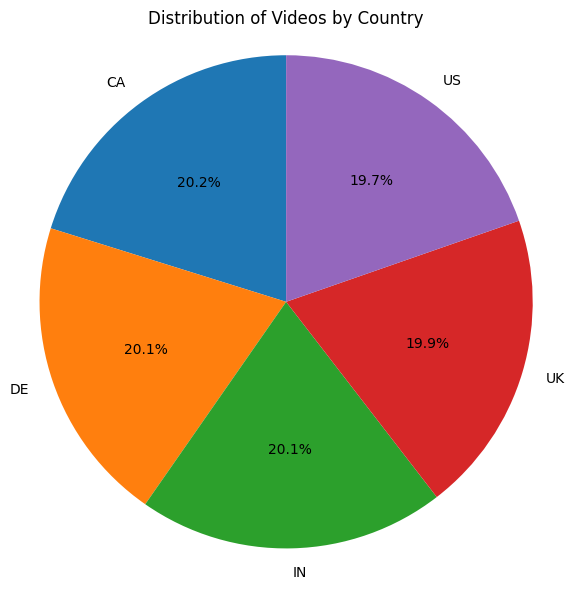

In [567]:
# 4. Distribution of Videos by Country


country_counts = X.filter(like='country_').sum().sort_values(ascending=False)

plt.figure(figsize=(7,7))
plt.pie(
    country_counts,
    labels=country_counts.index.str.replace('country_', ''),
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Videos by Country')
plt.axis('equal')
plt.show()

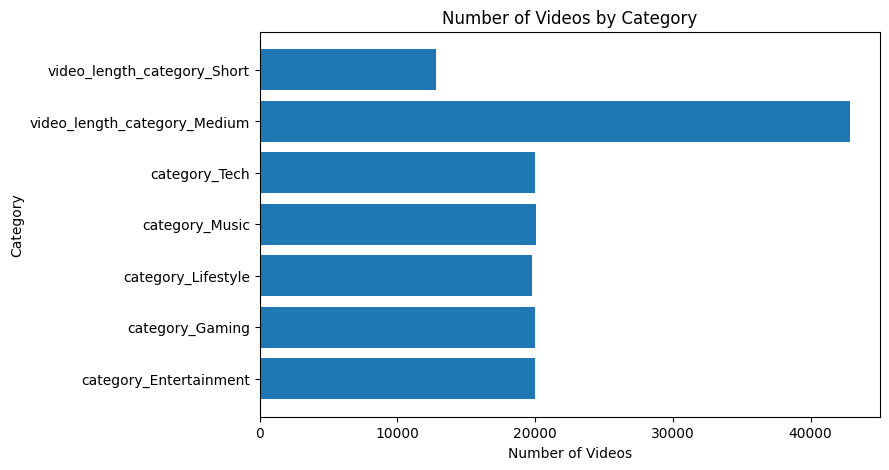

In [568]:
# Video counts based on Category 

category_counts = X.filter(like='category_').sum()

plt.figure(figsize=(8,5))
plt.barh(category_counts.index, category_counts.values)

plt.title('Number of Videos by Category')
plt.xlabel('Number of Videos')
plt.ylabel('Category')

plt.show()

# `Models`

In [569]:

#dependent variable
y = X['ad_revenue_usd']


# independent variables
X = X.drop(['ad_revenue_usd','date'], axis=1)


In [570]:
X.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,log_views,log_likes,log_comments,log_subscribers,...,country_UK,country_US,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,video_length_category_Medium,video_length_category_Short
0,9936,1221.0,320.0,26497.214184,2.862137,228086,9.204020,7.108244,5.771441,12.337482,...,False,False,False,False,False,False,True,False,False,True
1,10017,642.0,346.0,15209.747445,23.738069,736015,9.212139,6.466145,5.849325,13.509007,...,False,False,False,False,True,False,False,False,False,False
2,10097,1979.0,187.0,57332.658498,26.200634,240534,9.220093,7.590852,5.236442,12.390621,...,False,False,False,False,False,True,False,False,False,False
3,10034,1191.0,242.0,31334.517771,11.770340,434482,9.213834,7.083388,5.493061,12.981912,...,True,False,False,False,False,False,True,False,True,False
4,9889,1858.0,477.0,15665.666434,6.635854,42030,9.199279,7.527794,6.169611,10.646163,...,False,False,True,False,False,False,False,False,True,False


In [571]:
y.head()

0    203.178237
1    140.880508
2    360.134008
3    224.638261
4    165.514388
Name: ad_revenue_usd, dtype: float64

In [572]:
#splitting the data into test and train set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,  random_state=42)



In [573]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# `Linear Regression`

In [574]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print(lr_pred)

[352.90775505 342.33209882 204.48767854 ... 172.05191172 261.98918931
 285.65873425]


# `Ridge Regression`

In [575]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

print(ridge_pred)

[352.92653463 342.19096577 204.47875609 ... 172.12598659 262.00410001
 285.66404139]


# `Lasso Regression`

In [576]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

print(lasso_pred)

[352.72736051 341.66962439 204.63395182 ... 171.71731083 261.65082185
 285.41962674]


# `Decision Tree Regressor`

In [577]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print(dt_pred)

[352.50038968 341.62951699 204.61947512 ... 171.09398429 261.4422138
 287.89222881]


# `Random Forest`

In [578]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor( n_estimators=100,  random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(rf_pred)

[352.64615458 342.3485189  204.49648621 ... 170.87588747 262.88403325
 285.19684331]


# `Model Evaluation`

In [579]:
from sklearn.metrics import (r2_score,  mean_absolute_error,  mean_squared_error)

def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse


lr_results = evaluate_model(y_test, lr_pred)
ridge_results = evaluate_model(y_test, ridge_pred)
lasso_results = evaluate_model(y_test, lasso_pred)
dt_results = evaluate_model(y_test, dt_pred)
rf_results = evaluate_model(y_test, rf_pred)



results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'R2 Score': [
        lr_results[0],
        ridge_results[0],
        lasso_results[0],
        dt_results[0],
        rf_results[0]
    ],
    'MAE': [
        lr_results[1],
        ridge_results[1],
        lasso_results[1],
        dt_results[1],
        rf_results[1]
    ],
    'RMSE': [
        lr_results[2],
        ridge_results[2],
        lasso_results[2],
        dt_results[2],
        rf_results[2]
    ]
})

results.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,MAE,RMSE
2,Lasso Regression,0.952587,3.122556,13.478180
1,Ridge Regression,0.952573,3.145197,13.480211
0,Linear Regression,0.952572,3.146016,13.480310
4,Random Forest,0.949938,3.564123,13.849651
3,Decision Tree,0.897299,5.360109,19.836707


# `Manual Testing`


In [585]:

# Raw input values
views = 50000
likes = 4500
comments = 350
watch_time = 120000
video_length = 12
subscribers = 250000

new_data = pd.DataFrame({
    'views': [views],
    'likes': [likes],
    'comments': [comments],
    'watch_time_minutes': [watch_time],
    'video_length_minutes': [video_length],
    'subscribers': [subscribers],

    # Log Features
    'log_views': [np.log1p(views)],
    'log_likes': [np.log1p(likes)],
    'log_comments': [np.log1p(comments)],
    'log_subscribers': [np.log1p(subscribers)],

    # Date Features
    'year': [2025],
    'month': [9],
    'day': [24],

    # Engineered Features
    'engagement_rate': [(likes + comments) / views],
    'like_ratio': [likes / views],
    'watch_time_per_view': [watch_time / views],

    # Category (Tech)
    'category_Entertainment': [0],
    'category_Gaming': [0],
    'category_Lifestyle': [0],
    'category_Music': [0],
    'category_Tech': [1],

    # Device (Mobile)
    'device_Mobile': [1],
    'device_TV': [0],
    'device_Tablet': [0],

    # Country (India)
    'country_CA': [0],
    'country_DE': [0],
    'country_IN': [1],
    'country_UK': [0],
    'country_US': [0],

    # Day of Week (Wednesday)
    'day_of_week_Monday': [0],
    'day_of_week_Saturday': [0],
    'day_of_week_Sunday': [0],
    'day_of_week_Thursday': [0],
    'day_of_week_Tuesday': [0],
    'day_of_week_Wednesday': [1],

    # Video Length Category (Medium)
    'video_length_category_Medium': [1],
    'video_length_category_Short': [0]
})
new_data_scaled = scaler.transform(new_data)

prediction = lasso.predict(new_data_scaled)

print(f"Predicted Ad Revenue: ${prediction[0]:.2f}")

Predicted Ad Revenue: $931.73


In [586]:

# Raw input values
views = 20000
likes = 2500
comments = 150
watch_time = 80000
video_length = 5
subscribers = 50000

new_data = pd.DataFrame({
    'views': [views],
    'likes': [likes],
    'comments': [comments],
    'watch_time_minutes': [watch_time],
    'video_length_minutes': [video_length],
    'subscribers': [subscribers],

    # Log Features
    'log_views': [np.log1p(views)],
    'log_likes': [np.log1p(likes)],
    'log_comments': [np.log1p(comments)],
    'log_subscribers': [np.log1p(subscribers)],

    # Date Features
    'year': [2025],
    'month': [12],
    'day': [2],

    # Engineered Features
    'engagement_rate': [(likes + comments) / views],
    'like_ratio': [likes / views],
    'watch_time_per_view': [watch_time / views],

    # Category (Tech)
    'category_Entertainment': [0],
    'category_Gaming': [0],
    'category_Lifestyle': [0],
    'category_Music': [1],
    'category_Tech': [0],

    # Device (Mobile)
    'device_Mobile': [0],
    'device_TV': [0],
    'device_Tablet': [1],

    # Country (India)
    'country_CA': [0],
    'country_DE': [0],
    'country_IN': [0],
    'country_UK': [0],
    'country_US': [1],

    # Day of Week (Wednesday)
    'day_of_week_Monday': [0],
    'day_of_week_Saturday': [0],
    'day_of_week_Sunday': [0],
    'day_of_week_Thursday': [1],
    'day_of_week_Tuesday': [0],
    'day_of_week_Wednesday': [0],

    # Video Length Category (Medium)
    'video_length_category_Medium': [0],
    'video_length_category_Short': [1]
})
new_data_scaled = scaler.transform(new_data)

prediction = lasso.predict(new_data_scaled)

print(f"Predicted Ad Revenue: ${prediction[0]:.2f}")

Predicted Ad Revenue: $528.92


# `Pickling`

In [587]:
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(lasso, file)

In [588]:
# Assuming 'model' is your trained model
with open('model.pkl', 'wb') as file:
    pickle.dump(lasso, file)

In [589]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)